In [2]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

patient_data = "Person_01/rec_3"
ecg = wfdb.rdrecord(patient_data)
annotations = wfdb.rdann(patient_data, 'atr')
voltages = ecg.p_signal
print(ecg.sig_name)

['ECG I', 'ECG I filtered']


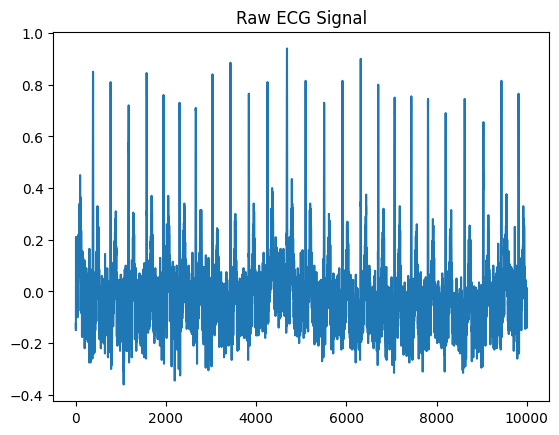

In [3]:
signal = voltages[:, 0]

x = range(len(signal))
#x = range(2000)
y = signal
plt.plot(x, y)
plt.title("Raw ECG Signal")
plt.show()

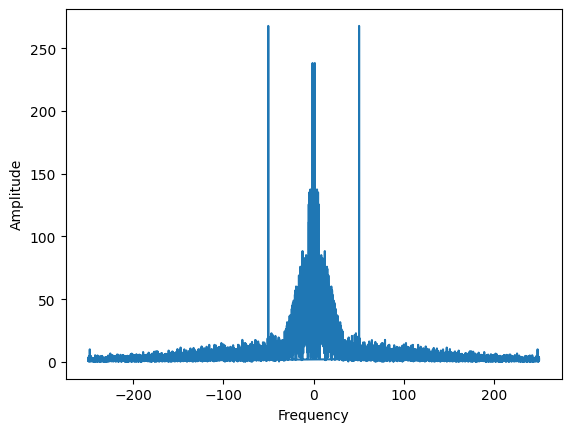

In [5]:
#Applying FFT

fs = 500
sig = signal

N = len(sig)
fft_vals = np.fft.fft(sig)
freqs = np.fft.fftfreq(N, d = 1/fs)

mag = np.abs(fft_vals)

ny = N//2

plt.plot(freqs, mag)
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

#Energy Ratio


def energyratio(sig, filtsig):
    raw_energy = np.sum(sig**2)
    filt_energy = np.sum(filtsig**2)
    print(f"Energy ratio: {filt_energy/raw_energy:.3f}")
    return filt_energy/raw_energy
    
def snr_imp(raw, filtered):
    raw = np.asarray(raw)
    filtered = np.asarray(filtered)
    
    # Noise removed by filtering
    noise_removed = raw - filtered
    
    # Power of filtered signal and removed noise
    signal_power = np.sum(filtered**2)
    noise_power = np.sum(noise_removed**2) + 1e-12  # avoid divide by zero
    
    # SNR improvement
    snr_imp = 10 * np.log10(signal_power / noise_power)
    print(f"SNR Improvement : {snr_imp:.3f}")
    return snr_imp
    
def spectral_entropy_change(raw, filt):
    def spec_entropy(sig):
        P = np.abs(rfft(sig))**2
        P = P / (np.sum(P) + 1e-12)
        return -np.sum(P * np.log2(P + 1e-12))
    print(f"Spectral Entropy Improvement: {(spec_entropy(raw) - spec_entropy(filt)):.3f}")
    return spec_entropy(raw) - spec_entropy(filt)
    
def ppr(raw, filt):
    raw_peaks = np.sum(raw > (np.mean(raw) + 0.5*np.std(raw)))
    filt_peaks = np.sum(filt > (np.mean(filt) + 0.5*np.std(filt)))
    print(f"Peak Preservation Ratio : {(filt_peaks / (raw_peaks + 1e-12)):.3f}") 
    return filt_peaks / (raw_peaks + 1e-12)

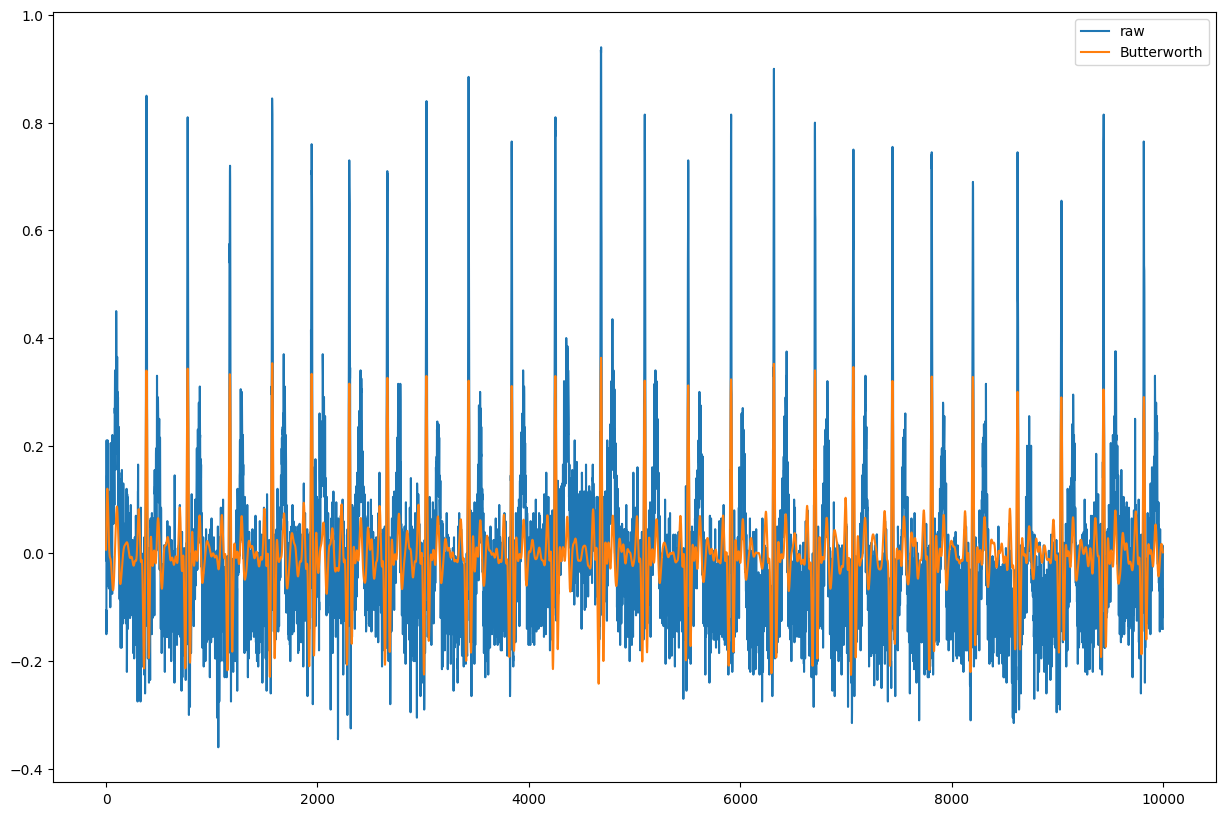

Energy ratio: 0.279
SNR Improvement : -3.505
Spectral Entropy Improvement: 1.421
Peak Preservation Ratio : 0.818


np.float64(0.8182746299132206)

In [6]:
#Applying Butterworth Filter with 4 convolutions

from scipy.signal import butter, filtfilt, lfilter
from scipy.fft import rfft, rfftfreq

l, h = 5, 15

b, a = butter(
    N=4,
    Wn = [l, h],
    btype = 'bandpass',
    fs = 500
)

filtsig = filtfilt(b, a, sig)

plt.figure(figsize=(15, 10))
plt.plot(sig, label='raw')
plt.plot(filtsig, label='Butterworth')
plt.legend()
plt.show()

energyratio(sig, filtsig)
snr_imp(sig, filtsig)
spectral_entropy_change(sig, filtsig)
ppr(sig, filtsig)

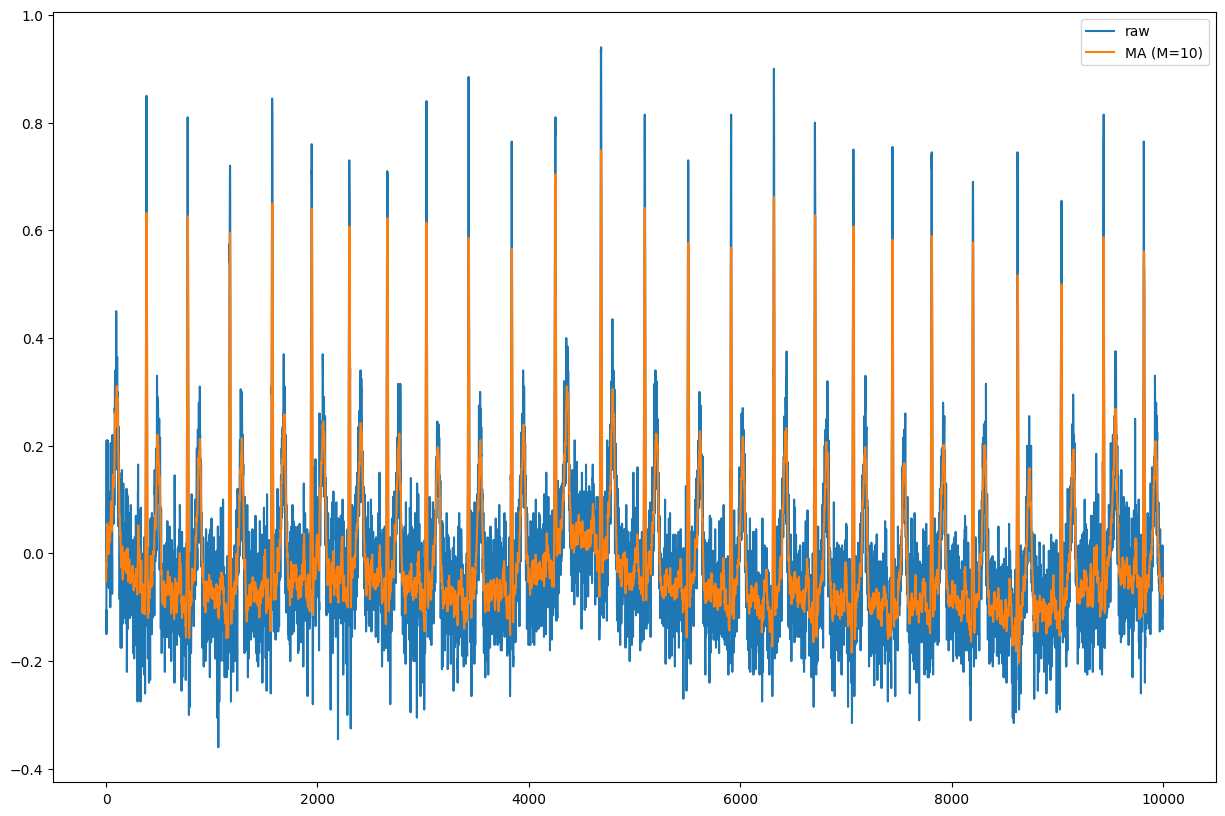

Energy ratio: 0.706
SNR Improvement : 5.694
Spectral Entropy Improvement: 0.920
Peak Preservation Ratio : 0.952


np.float64(0.9515058703420108)

In [7]:
#Moving Average Filter

M = 10 # window size
filtsig = np.convolve(sig, np.ones(M)/M, mode='same')

plt.figure(figsize=(15,10))
plt.plot(sig, label='raw')
plt.plot(filtsig, label=f'MA (M={M})')
plt.legend()
plt.show()

energyratio(sig, filtsig)
snr_imp(sig, filtsig)
spectral_entropy_change(sig, filtsig)
ppr(sig, filtsig)

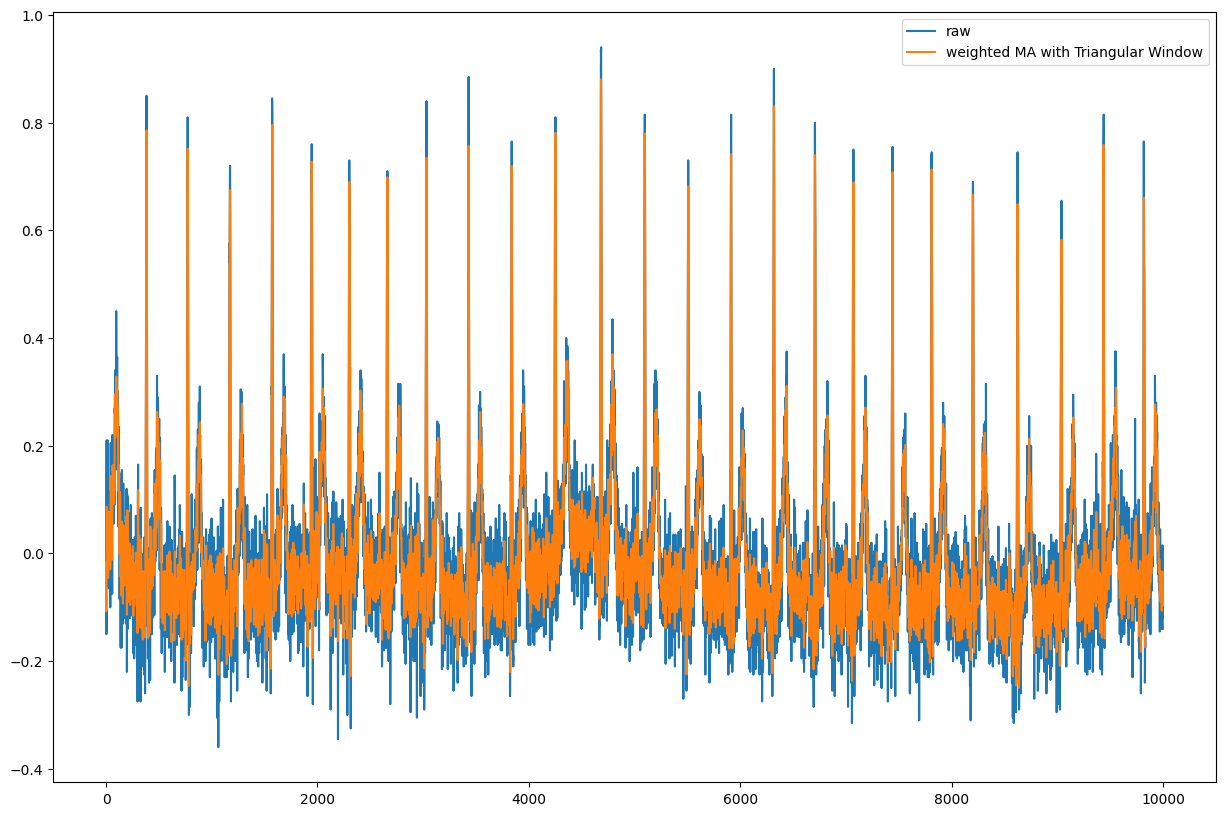

Energy ratio: 0.848
SNR Improvement : 10.542
Spectral Entropy Improvement: 0.552
Peak Preservation Ratio : 0.947


np.float64(0.9474221541602854)

In [17]:
#Weighted Moving Average Filter

weights = np.array([6, 7, 7, 7, 6]) #Simple Triangular Window
weights = weights / np.sum(weights)
filtsig = np.convolve(sig, weights, mode='same')

plt.figure(figsize=(15,10))
plt.plot(sig, label='raw')
plt.plot(filtsig, label='weighted MA with Triangular Window')
plt.legend()
plt.show()

energyratio(sig, filtsig)
snr_imp(sig, filtsig)
spectral_entropy_change(sig, filtsig)
ppr(sig, filtsig)

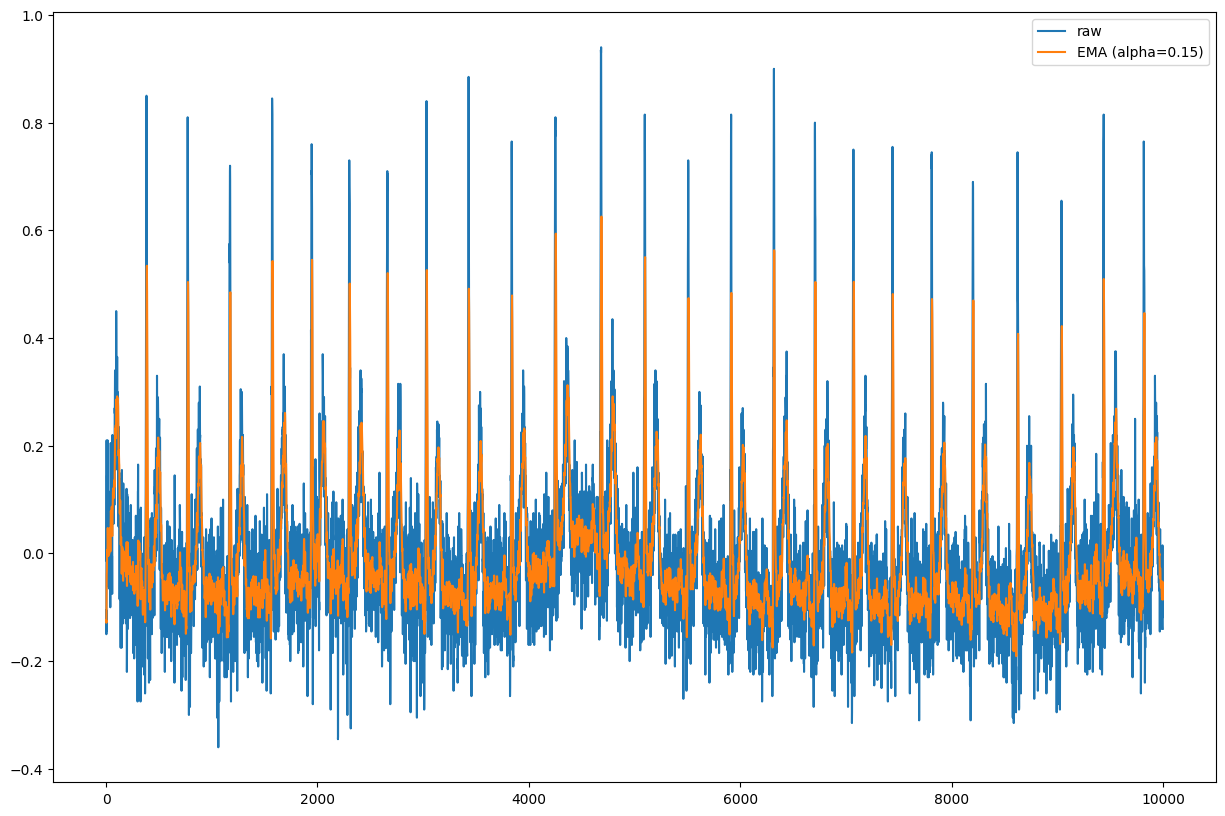

Energy ratio: 0.582
SNR Improvement : 2.135
Spectral Entropy Improvement: 1.206
Peak Preservation Ratio : 1.023


np.float64(1.0229709035222048)

In [20]:
#Exponential Moving Average Filter

alpha = 0.15

filtsig = np.zeros(len(sig))
filtsig[0] = sig[0]

for n in range(1, len(sig)):
    filtsig[n] = alpha * sig[n] + (1 - alpha) * filtsig[n-1]

plt.figure(figsize=(15,10))
plt.plot(sig, label='raw')
plt.plot(filtsig, label=f'EMA (alpha={alpha})')
plt.legend()
plt.show()

energyratio(sig, filtsig)
snr_imp(sig, filtsig)
spectral_entropy_change(sig, filtsig)
ppr(sig, filtsig)

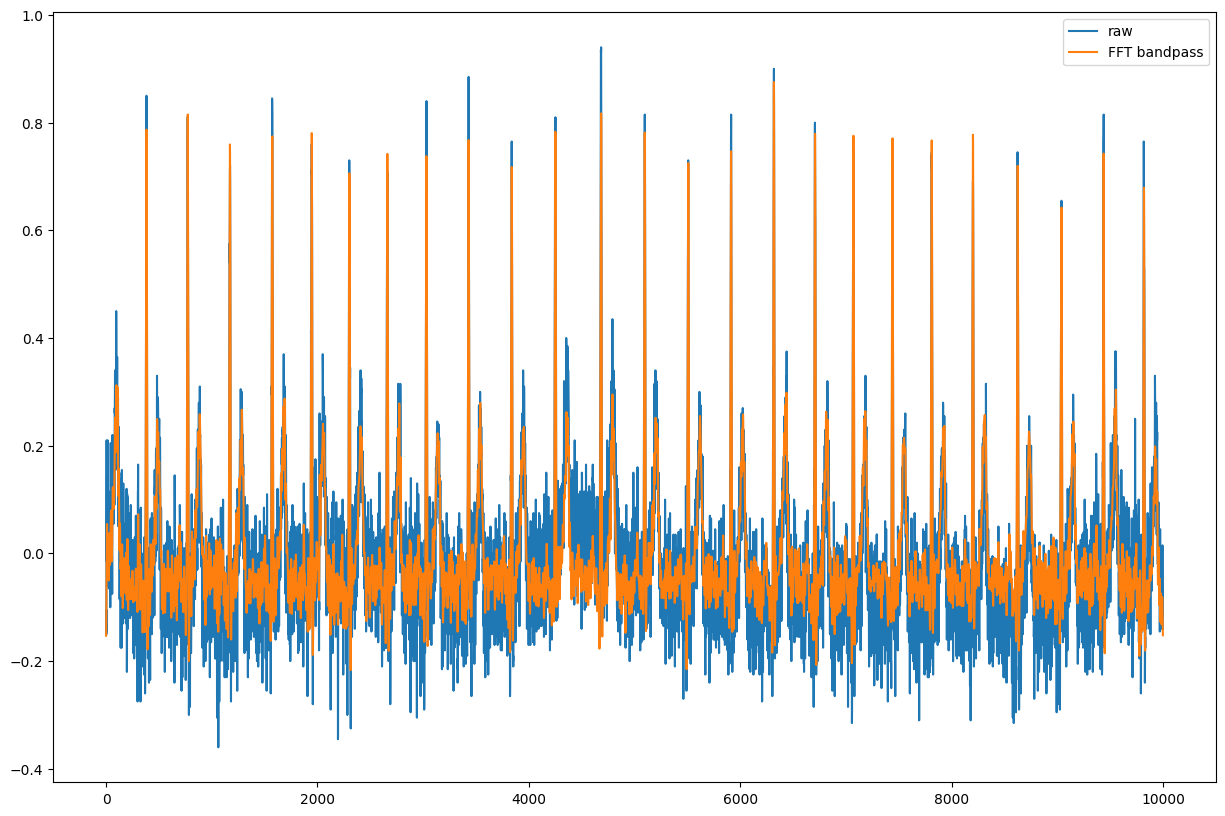

Energy ratio: 0.809
SNR Improvement : 6.274
Spectral Entropy Improvement: 0.456
Peak Preservation Ratio : 0.869


np.float64(0.8693210821847878)

In [10]:
#Band Pass Filter

X = np.fft.fft(sig)
N = len(sig)
freqs = np.fft.fftfreq(N, d=1/fs)

# Define band
low = 0.5
high = 50

# Create mask
mask = (np.abs(freqs) >= low) & (np.abs(freqs) <= high)

# Apply bandpass
X_filtered = X * mask

filtsig = np.real(np.fft.ifft(X_filtered))
plt.figure(figsize=(15,10))
plt.plot(sig, label='raw')
plt.plot(filtsig, label='FFT bandpass')
plt.legend()
plt.show()
energyratio(sig, filtsig)
snr_imp(sig, filtsig)
spectral_entropy_change(sig, filtsig)
ppr(sig, filtsig)

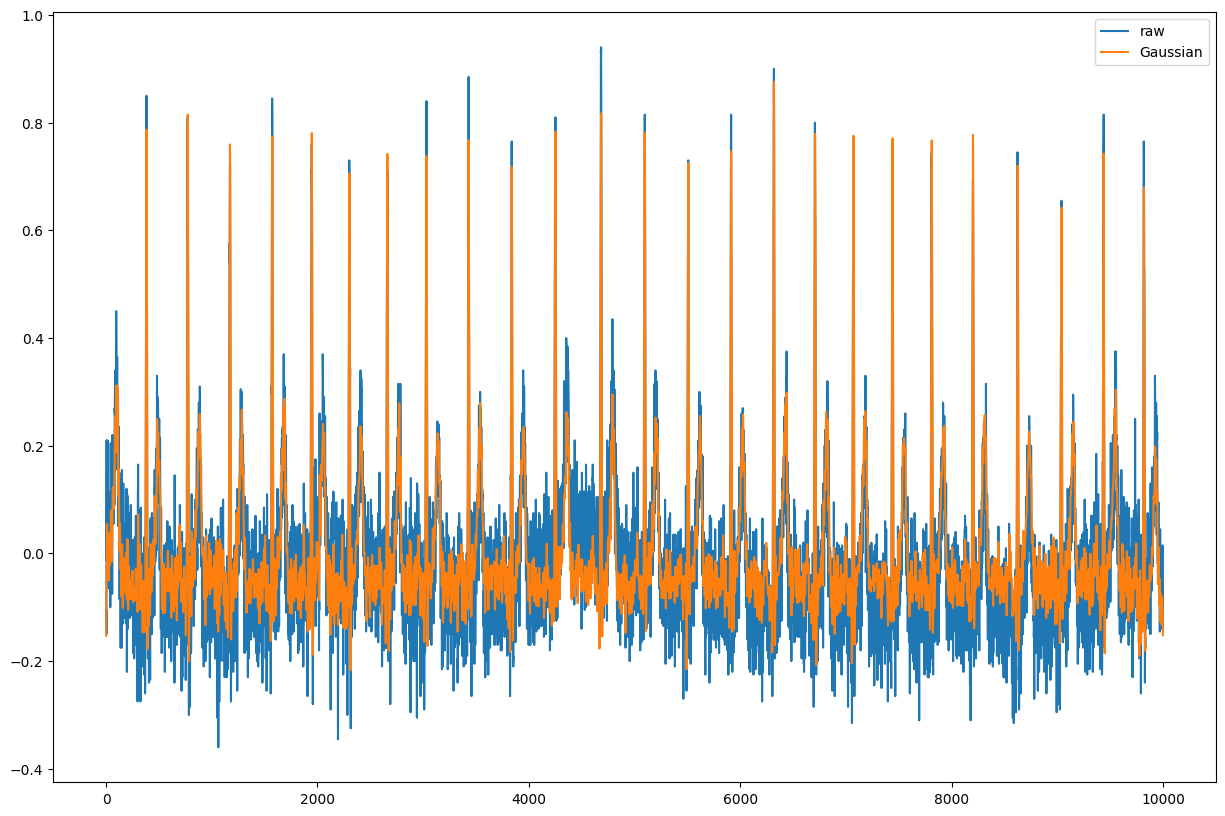

Energy ratio: 0.809
SNR Improvement : 6.274
Spectral Entropy Improvement: 0.456
Peak Preservation Ratio : 0.869


np.float64(0.8693210821847878)

In [11]:
#Gaussian Filter

sigma = 2
M = sigma*6  # window size

x = np.linspace(-(M//2), M//2, M)
weights = np.exp(-x**2 / (2*sigma**2))
weights = weights / np.sum(weights)

gsig = np.convolve(sig, weights, mode='same')

plt.figure(figsize=(15,10))
plt.plot(sig, label='raw')
plt.plot(filtsig, label='Gaussian')
plt.legend()
plt.show()

energyratio(sig, filtsig)
snr_imp(sig, filtsig)
spectral_entropy_change(sig, filtsig)
ppr(sig, filtsig)